In [70]:
import operator
import time
import random
import requests
from typing import TypedDict, Literal, Optional, Annotated, List
from pydantic import BaseModel, Field
from datetime import datetime

import numpy as np
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver

In [71]:
# ============================================================
# 1. STATE SCHEMAS
# ============================================================

class SensorData(BaseModel):
    """Mock sensor readings from RGB camera and SLAM."""
    front_car_distance: float = Field(description="Distance to the front car (meters)")
    front_car_speed: float = Field(description="Estimated speed of the front car (m/s)")
    front_car_length: float = Field(description="Estimated length of the front car (meters)", default=4.5)
    back_car_distance: float = Field(description="Distance to the back car in passing lane (meters)", default=100.0)
    back_car_closing_rate: float = Field(description="Rate at which back car is closing in (m/s, positive=closing)", default=0.0)
    passing_lane_front_distance: float = Field(description="Distance to nearest car in passing lane ahead (meters)", default=200.0)
    passing_lane_front_distance_trend: Literal["increasing", "constant", "decreasing"] = Field(
        description="Whether the distance to the passing lane front car is increasing, constant, or decreasing",
        default="constant"
    )
    num_cars_in_safety_zone: int = Field(description="Number of cars detected in the 100m safety zone ahead", default=0)
    hazard_detected: bool = Field(description="Whether a hazard is detected in the safety interval", default=False)
    next_front_car_distance: float = Field(description="Distance to the car ahead of the front car (meters)", default=50.0)
    ego_speed: float = Field(description="Current speed of the ego vehicle (m/s)", default=15.0)
    speed_limit: float = Field(description="Speed limit of the current road (m/s)", default=30.0)




In [72]:
class TravelRequest(BaseModel):
    """Parsed travel request from user input."""
    starting_point: str = Field(description="Starting location")
    goal: str = Field(description="Destination")
    aggressive_level: Literal["0", "low", "high"] = Field(description="Driving urgency level: 0=no passing ever, low=pass rarely, high=pass aggressively")



In [73]:
class NavigationPlan(BaseModel):
    """LLM-generated navigation plan based on the city map."""
    route_description: str = Field(description="Human-readable description of the planned route")
    waypoints: List[Waypoint] = Field(description="Ordered list of waypoints along the route")
    estimated_time_s: float = Field(description="Estimated total travel time in seconds")
    passing_opportunities: List[str] = Field(description="List of street names where passing might be possible (multi-lane, dashed lines)")


In [74]:
class PassingPlan(BaseModel):
    """LLM-generated passing maneuver plan."""
    overtake_maneuver: list = Field(description="Steps to overtake: list of dicts with lane_change, acceleration (m/s²), accelerate_time (s)")
    merge_back_maneuver: list = Field(description="Steps to merge back: list of dicts with lane_change direction")
    route_after_pass: list = Field(description="Updated waypoints after completing the pass")
    reasoning: str = Field(description="Why this plan was chosen given the sensor data")

In [75]:
class Waypoint(BaseModel):
    """A single waypoint in a navigation plan."""
    street: str = Field(description="Street name for this waypoint")
    action: str = Field(description="Action at this waypoint: drive, turn_left, turn_right, or merge")
    speed: float = Field(description="Target speed in m/s (must respect speed limit)")

In [76]:
class OvertakeStep(BaseModel):
    """A single step in an overtake maneuver."""
    lane_change: str = Field(description="Direction to change lane: left or right")
    acceleration: float = Field(description="Acceleration in m/s²")
    accelerate_time: float = Field(description="Duration to accelerate in seconds")


In [77]:
class MergeBackStep(BaseModel):
    """A single step to merge back after overtaking."""
    lane_change: str = Field(description="Direction to merge back: left or right")

In [78]:
class PassingPlan(BaseModel):
    """LLM-generated passing maneuver plan."""
    overtake_maneuver: List[OvertakeStep] = Field(description="Steps to overtake the front car")
    merge_back_maneuver: List[MergeBackStep] = Field(description="Steps to merge back into the original lane")
    route_after_pass: List[Waypoint] = Field(description="Updated waypoints from post-pass position to destination")
    reasoning: str = Field(description="Why this plan was chosen given the sensor data")

In [79]:
# --- Sub-states: each groups fields owned by a specific node ---
"""
Node 1: extract_request
Node 2: navigate
Node 3: check_passing_lane_front
Node 4: check_passing_lane_back
Node 5: checker
Node 6: analyze_current_lane
Node 7: send_passing_signal
Node 8: carla_executor

"""
class InputState(TypedDict):
    """Raw user input. Written by the user, read by Node 1 (extract_request)."""
    travel_request: str                       # e.g. "Rush to the airport in 5 min"


class ExtractedRequestState(InputState):
    """Parsed travel info. Written by Node 1, read by Nodes 2 & 7."""
    starting_point: str
    goal: str
    aggressive_level: str                     # "0", "low", or "high"
    original_aggressive_level: str            # Saved for reset after temporary lowering


class NavigationState(ExtractedRequestState):
    """Route plan + sensor snapshot. Written by Node 2 (navigate), read by Nodes 3-6 & 8."""
    navigation_plan: list                     # List of waypoints / movement decisions
    current_waypoint_index: int               # Index of current waypoint in the plan
    current_position: str                     # Current position on the route
    sensor_data: dict                         # SensorData as dict
    passing_available: bool                   # Whether passing opportunity exists
    trip_elapsed_time: float                  # Seconds elapsed since trip started
    trip_eta: float                           # Estimated total travel time in seconds
    depth_check_interval: float              # Seconds between depth estimation checks
    last_depth_check_time: float             # Timestamp of last depth estimation check
    arrived: bool                             # Whether the vehicle has reached the destination


class PassingLaneState(NavigationState):
    """Passing lane verdicts. Written by Nodes 3 & 4, read by Node 5 (checker)."""
    front_approval: bool                      # Passing Lane Front approval
    back_approval: bool                       # Passing Lane Back approval
    passing_side: str                         # "left" or "right" — which side was approved
    


class CheckerState(PassingLaneState):
    """Checker verdict. Written by Node 5, read by Node 7 (send_passing_signal)."""
    checker_result: str                       # "approved" or "disapproved"


class CurrentLaneState(CheckerState):
    """Current lane verdict. Written by Node 6, read by Node 7."""
    current_lane_result: str                  # "approve" or "disapprove"


class AggressionTrackingState(CurrentLaneState):
    """Disapproval tracking + adaptive aggression. Written/read by Node 7."""
    consecutive_disapprovals: int             # Count of consecutive no-pass decisions
    last_disapproval_time: float              # Timestamp of last disapproval
    aggression_lowered_until: float           # Timestamp when aggression reset


class PassingExecutionState(AggressionTrackingState):
    """Passing decision + instructions. Written by Node 7 & Node 2 (Mode 2)."""
    passing_signal: str                       # "pass" or "no_pass" — sent from passing subgraph back to Navigate
    # When passing:
    #   overtake_maneuver: [{"lane_change": "left"/"right", "acceleration": float, "accelerate_time": float}]
    #   merge_back_maneuver: [{"lane_change": "left"/"right"}]
    # When no pass: both lists are empty
    passing_instructions: dict                # {"overtake_maneuver": [...], "merge_back_maneuver": [...]}


class ControlState(PassingExecutionState):
    """Loop control + message history. Shared infrastructure."""
    should_continue_driving: bool             # Whether to keep the driving loop going
    messages: Annotated[list, operator.add]   # Message history for LLM interactions


class AutoPassingState(ControlState):
    """Complete graph state — composes all sub-states via inheritance.
    Use this as the single source of truth for StateGraph(AutoPassingState).
    """
    pass



In [80]:
# ============================================================
# 2. MAP SERVER CLIENT
# ============================================================

MAP_SERVER_URL = "http://127.0.0.1:8100/map"

def pull_map_from_server() -> dict:
    """
    Pull the city map from the local map server.
    The map is built by the patrolling program and uploaded to the server.
    This is the Navigate node's long-term memory.

    Returns:
        dict: The city map with streets, intersections, and landmarks.
              Returns a fallback empty map if the server is unreachable.
    """
    try:
        response = requests.get(MAP_SERVER_URL, timeout=5)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"[WARNING] Could not reach map server at {MAP_SERVER_URL}: {e}")
        print("[WARNING] Using empty fallback map — start map_server.py first.")
        return {
            "version": 0,
            "city": "unknown",
            "streets": [],
            "intersections": [],
            "landmarks": [],
        }

In [81]:
# ============================================================
# 3. PERCEPTION TOOLS (dummy — to be replaced by your group)
# ============================================================

def run_segmentation(rgb_image: np.ndarray) -> dict:
    """
    Segmentation model that identifies objects in the camera frame.

    YOUR GROUP WILL REPLACE THIS with a real model (e.g., Mask R-CNN,
    YOLO-seg, or any instance segmentation network).

    Args:
        rgb_image: np.ndarray of shape (H, W, 3), uint8 RGB image
                   from the ego vehicle's front-facing camera.

    Returns:
        dict with:
            "car_masks": list of dicts, one per detected car:
                - "bbox": [x1, y1, x2, y2] pixel coordinates
                - "mask": np.ndarray (H, W) binary mask for this car
                - "confidence": float 0-1
                - "label": str, e.g. "car", "truck", "motorcycle"
            "lane_lines": list of dicts, one per detected lane line:
                - "points": list of [x, y] pixel coordinates along the line
                - "type": "solid" or "dashed"
                - "side": "left", "right", or "center"
            "hazards": list of dicts for non-vehicle obstacles:
                - "bbox": [x1, y1, x2, y2]
                - "label": str, e.g. "pedestrian", "cone", "debris"
                - "confidence": float 0-1
            "drivable_area": np.ndarray (H, W) binary mask of drivable surface
    """
    # --- DUMMY IMPLEMENTATION ---
    # Returns mock data that mimics what a real segmentation model would produce.
    H, W = rgb_image.shape[:2] if rgb_image is not None else (720, 1280)

    # Mock: detect 1-3 cars at random positions
    num_cars = random.randint(1, 3)
    car_masks = []
    for i in range(num_cars):
        cx = random.randint(W // 4, 3 * W // 4)
        cy = random.randint(H // 3, 2 * H // 3)
        bw, bh = random.randint(60, 150), random.randint(40, 100)
        car_masks.append({
            "bbox": [cx - bw // 2, cy - bh // 2, cx + bw // 2, cy + bh // 2],
            "mask": np.zeros((H, W), dtype=np.uint8),  # placeholder
            "confidence": round(random.uniform(0.7, 0.99), 2), # two digits accuracy
            "label": random.choice(["car", "car", "car", "truck"]),
        })

    # Mock: detect lane lines
    lane_lines = [
        {"points": [[W // 3, H], [W // 3, H // 2]], "type": "dashed", "side": "left"},
        {"points": [[2 * W // 3, H], [2 * W // 3, H // 2]], "type": "solid", "side": "right"},
    ]

    # Mock: no hazards most of the time
    hazards = []
    if random.random() < 0.1:
        hazards.append({
            "bbox": [random.randint(0, W - 50), random.randint(H // 2, H - 50),
                      random.randint(50, W), random.randint(H // 2, H)],
            "label": random.choice(["pedestrian", "cone", "debris"]),
            "confidence": round(random.uniform(0.5, 0.9), 2),
        })

    return {
        "car_masks": car_masks,
        "lane_lines": lane_lines,
        "hazards": hazards,
        "drivable_area": np.ones((H, W), dtype=np.uint8),  # placeholder
    }

In [82]:
def run_depth_estimation(rgb_image: np.ndarray) -> dict:
    """
    Monocular depth estimation model that produces a depth map from a single
    RGB image.

    YOUR GROUP WILL REPLACE THIS with a real model (e.g., MiDaS, ZoeDepth,
    Depth Anything, or stereo depth from Carla's depth camera).

    Args:
        rgb_image: np.ndarray of shape (H, W, 3), uint8 RGB image
                   from the ego vehicle's front-facing camera.

    Returns:
        dict with:
            "depth_map": np.ndarray of shape (H, W), float32, values in meters.
                         Each pixel is the estimated distance from the camera.
            "min_depth": float, closest object distance in meters
            "max_depth": float, farthest estimated distance in meters
            "car_distances": list of dicts, one per detected car region:
                - "bbox": [x1, y1, x2, y2] pixel coordinates (same as segmentation)
                - "median_depth": float, median depth within the car's bounding box (meters)
                - "min_depth": float, closest point of the car (meters)
                - "position": "front", "front_left", "front_right", "rear_left", "rear_right"
                              relative to ego vehicle
    """
    # --- DUMMY IMPLEMENTATION ---
    # Returns mock data that mimics what a real depth model would produce.
    H, W = rgb_image.shape[:2] if rgb_image is not None else (720, 1280)

    # Mock depth map: gradient from near (bottom) to far (top)
    depth_map = np.linspace(5.0, 200.0, H).reshape(-1, 1).repeat(W, axis=1).astype(np.float32)
    # Add some noise
    depth_map += np.random.normal(0, 2.0, (H, W)).astype(np.float32)
    depth_map = np.clip(depth_map, 1.0, 300.0)

    # Mock car distances
    car_distances = [
        {
            "bbox": [W // 2 - 75, H // 2 - 50, W // 2 + 75, H // 2 + 50],
            "median_depth": round(random.uniform(20, 80), 1),
            "min_depth": round(random.uniform(15, 70), 1),
            "position": "front",
        },
    ]

    # Sometimes add a car in the passing lane
    if random.random() < 0.5:
        car_distances.append({
            "bbox": [W // 4 - 60, H // 2 - 40, W // 4 + 60, H // 2 + 40],
            "median_depth": round(random.uniform(50, 200), 1),
            "min_depth": round(random.uniform(40, 180), 1),
            "position": random.choice(["front_left", "rear_left"]),
        })

    return {
        "depth_map": depth_map,
        "min_depth": float(np.min(depth_map)),
        "max_depth": float(np.max(depth_map)),
        "car_distances": car_distances,
    }

In [83]:
# ============================================================
# 3b. MULTI-FRAME PERCEPTION PIPELINE
# ============================================================

# Camera parameters (for estimating real-world car length from bbox)
CAMERA_FOV_DEG = 90.0        # horizontal field of view in degrees
CAMERA_WIDTH_PX = 1280       # image width in pixels
CAMERA_FOCAL_PX = CAMERA_WIDTH_PX / (2 * np.tan(np.radians(CAMERA_FOV_DEG / 2)))


def capture_multi_frame_perception(
    num_frames: int = 5,
    interval_s: float = 0.4,
    image_shape: tuple = (720, 1280, 3),
) -> dict:
    """
    Captures a burst of frames over a short time window and runs both
    segmentation + depth estimation on each frame. Then computes derived
    quantities from the sequence:

    - front_car_speed: from change in front car depth across frames
    - front_car_length: from segmentation bbox width + depth (pinhole model)
    - back_car_closing_rate: from change in rear car depth across frames
    - hazard_detected: True if any frame detected a hazard via segmentation

    Args:
        num_frames: number of frames to capture (default 5)
        interval_s: seconds between frames (default 0.4 → 2.5 FPS over 2s)
        image_shape: (H, W, 3) shape for the mock RGB images

    Returns:
        dict with:
            "depth_result": the LAST frame's depth estimation output
                            (used for distances — most recent snapshot)
            "seg_result": the LAST frame's segmentation output
            "front_car_speed": float, estimated speed in m/s
            "front_car_length": float, estimated length in meters
            "back_car_closing_rate": float, rate in m/s (positive = closing)
            "hazard_detected": bool, True if any hazard seen in any frame
            "num_frames": int, how many frames were actually processed
    """
    # Collect per-frame measurements
    front_depths = []       # depth of closest front car per frame
    rear_depths = []        # depth of closest rear car per frame
    front_bboxes = []       # (bbox_width_px, depth) for car length estimation
    any_hazard = False

    last_depth_result = None
    last_seg_result = None

    for i in range(num_frames):
        mock_rgb = np.zeros(image_shape, dtype=np.uint8)

        depth_result = run_depth_estimation(mock_rgb)
        seg_result = run_segmentation(mock_rgb)

        last_depth_result = depth_result
        last_seg_result = seg_result

        # --- Track front car depth ---
        front_cars = [c for c in depth_result["car_distances"]
                      if c["position"] == "front"]
        if front_cars:
            closest = min(front_cars, key=lambda c: c["median_depth"])
            front_depths.append(closest["median_depth"])
            # Save bbox width for length estimation
            bbox = closest["bbox"]  # [x1, y1, x2, y2]
            bbox_width_px = bbox[2] - bbox[0]
            front_bboxes.append((bbox_width_px, closest["median_depth"]))
        else:
            front_depths.append(None)

        # --- Track rear car depth ---
        rear_cars = [c for c in depth_result["car_distances"]
                     if c["position"] in ("rear_left", "rear_right")]
        if rear_cars:
            closest_rear = min(rear_cars, key=lambda c: c["median_depth"])
            rear_depths.append(closest_rear["median_depth"])
        else:
            rear_depths.append(None)

        # --- Check for hazards in segmentation ---
        if seg_result["hazards"]:
            any_hazard = True

    # ==========================================================
    # Compute derived quantities from the frame sequence
    # ==========================================================

    # --- Front car speed ---
    # Speed = change in depth / time between frames
    # Use linear regression over all valid frames for a smoother estimate
    valid_front = [(i, d) for i, d in enumerate(front_depths) if d is not None]
    if len(valid_front) >= 2:
        times = np.array([v[0] * interval_s for v in valid_front])
        depths = np.array([v[1] for v in valid_front])
        # depth_change_rate = how fast the front car's distance is changing
        # Negative rate = car getting closer (ego faster), positive = pulling away
        # Use polyfit for a simple linear fit: depth = slope * t + intercept
        slope, _ = np.polyfit(times, depths, 1)
        # The front car's speed relative to ego:
        # If ego is going 15 m/s and depth is decreasing at 5 m/s,
        # front car is going ~10 m/s
        # front_car_relative_speed = -slope (positive slope = pulling away)
        # Absolute speed = ego_speed + slope (slope negative = slower car)
        # For now, estimate absolute speed as ego_speed + slope
        # We'll use 15 m/s as default ego speed; the caller can override
        front_car_speed = max(0.0, 15.0 + slope)  # clamp to non-negative
    else:
        front_car_speed = random.uniform(8, 14)  # fallback if not enough data

    # --- Front car length ---
    # Pinhole camera model: real_width = (bbox_width_px / focal_length_px) × depth
    # This gives the width of the car. Length ≈ width × aspect_ratio (~2.0 for sedans)
    CAR_LENGTH_TO_WIDTH_RATIO = 2.0
    valid_lengths = []
    for bbox_w, depth in front_bboxes:
        if bbox_w > 0 and depth > 0:
            real_width = (bbox_w / CAMERA_FOCAL_PX) * depth
            estimated_length = real_width * CAR_LENGTH_TO_WIDTH_RATIO
            # Clamp to reasonable range (2m motorcycle — 20m truck)
            estimated_length = np.clip(estimated_length, 2.0, 20.0)
            valid_lengths.append(estimated_length)

    if valid_lengths:
        front_car_length = float(np.median(valid_lengths))  # median for robustness
    else:
        front_car_length = 4.5  # fallback default sedan length

    # --- Back car closing rate ---
    # closing_rate = how fast the gap is shrinking (positive = closing in)
    valid_rear = [(i, d) for i, d in enumerate(rear_depths) if d is not None]
    if len(valid_rear) >= 2:
        times_r = np.array([v[0] * interval_s for v in valid_rear])
        depths_r = np.array([v[1] for v in valid_rear])
        slope_r, _ = np.polyfit(times_r, depths_r, 1)
        # Negative slope = distance decreasing = car closing in
        back_car_closing_rate = -slope_r  # positive means closing
    else:
        back_car_closing_rate = 0.0  # fallback: assume not closing

    return {
        "depth_result": last_depth_result,
        "seg_result": last_seg_result,
        "front_car_speed": round(front_car_speed, 1),
        "front_car_length": round(front_car_length, 1),
        "back_car_closing_rate": round(back_car_closing_rate, 1),
        "hazard_detected": any_hazard,
        "num_frames": num_frames,
    }

In [84]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [85]:
# ============================================================
# 4. NODE DEFINITIONS
# ============================================================

# --- Node 1: Input Extractor (LLM-based + human-in-the-loop) ---
def extract_travel_request(state: InputState) -> dict:
    """
    LLM-powered node that parses a travel request like
    'I need to go to XXX in 10 minutes' and extracts:
    starting_point, goal, aggressive_level.

    If the user didn't specify a starting point, the graph pauses
    and asks the user for their current location using interrupt().
    The graph resumes when the user provides the answer.
    """
    travel_request = state["travel_request"]

    structured_llm = llm.with_structured_output(TravelRequest)

    system_message = """You are a travel request parser for an autonomous vehicle.

    Extract the following from the user's request:
    1. starting_point: Where they are starting from (use "unknown" if not specified)
    2. goal: Where they want to go
    3. aggressive_level — three levels of driving urgency:
       - "0" if the user explicitly says no passing, stay in lane, safe mode, or similar
       - "low" if the request is relaxed, has generous time, or no time pressure
       - "high" if the request implies urgency (tight time constraints, words like "hurry", "rush", "ASAP")

    Examples:
    - "I need to go to the airport in 10 minutes" → starting_point: "unknown", aggressive_level: "high"
    - "Take me from downtown to the mall, no rush" → starting_point: "downtown", aggressive_level: "low"
    - "Drive to downtown in 5 minutes" → starting_point: "unknown", aggressive_level: "high"
    - "Go to the office" → starting_point: "unknown", aggressive_level: "low"
    - "Drive me home, stay in lane" → starting_point: "unknown", aggressive_level: "0"
    - "Safe mode to the hospital" → starting_point: "unknown", aggressive_level: "0"
    """

    result = structured_llm.invoke(
        [SystemMessage(content=system_message),
         HumanMessage(content=travel_request)]
    )

    starting_point = result.starting_point

    # If the user didn't specify a starting point, ask them
    if starting_point.lower() in ("unknown"):
        starting_point = interrupt("What is your current location?")

    return {
        "starting_point": starting_point,
        "goal": result.goal,
        "aggressive_level": result.aggressive_level,
        "original_aggressive_level": result.aggressive_level,
        "messages": [HumanMessage(content=f"Travel request parsed: {starting_point} → {result.goal}, aggression: {result.aggressive_level}")],
    }

In [126]:
# --- Node 2: Navigation (LLM-based + map server) ---
def navigate(state: AutoPassingState) -> dict:
    """
    Navigate has THREE modes, forming a driving loop:

    MODE 1 — Plan route (first visit, no navigation_plan yet):
      Pulls the city map from the local server (long-term memory),
      feeds it + the travel request to the LLM, and gets back a
      navigation plan. Initializes trip tracking fields.

    MODE 2 — Generate passing plan (after passing decision):
      Receives passing_signal from the passing subgraph.
      If "pass": LLM generates passing maneuver + replans route.
      If "no_pass": empty instructions, plan unchanged.

    MODE 3 — Continue driving (loop-back from executor):
      Advances along the planned route waypoint by waypoint.
      Checks arrival. Runs interval-based depth estimation
      based on urgency level to detect new front cars.
      If a front car is detected → sets passing_available=True.

    Mode detection:
      - navigation_plan is empty/missing → Mode 1
      - passing_signal is "pass" or "no_pass" → Mode 2
      - otherwise (plan exists, no pending signal) → Mode 3
    """

    passing_signal = state.get("passing_signal", "")
    has_plan = len(state.get("navigation_plan", [])) > 0

    # ==============================================
    # MODE 2: Generate passing plan (return visit)
    # ==============================================
    if passing_signal in ("pass", "no_pass"):

        sensor = SensorData(**state["sensor_data"])

        if passing_signal == "pass":
            # --- Build passing maneuver from pre-computed physics ---
            # The physics (target_velocity, acceleration, required_time) were
            # computed by analyze_current_lane (Node 6). Navigate Mode 2 just
            # uses those values for the maneuver and asks the LLM to replan the route.
            passing_side = state.get("passing_side", "left")
            merge_back_side = "right" if passing_side == "left" else "left"

            # Pre-computed by analyze_current_lane
            target_velocity = state.get("passing_target_velocity", 0.0)
            accel = state.get("passing_acceleration", 0.0)
            req_time = state.get("passing_required_time", 0.0)

            # --- LLM only replans the route after the pass ---
            replan_prompt = f"""You are a navigation planner for an autonomous vehicle.
The vehicle has just completed a passing maneuver. Replan the remaining route.

PASS DETAILS:
- Passing side: {passing_side.upper()}
- Target velocity reached: {target_velocity:.1f} m/s
- Acceleration used: {accel:.2f} m/s²
- Maneuver duration: {req_time:.1f}s
- The vehicle is now in the {passing_side} lane, ahead of the passed car

ORIGINAL ROUTE (before pass):
{json.dumps(state.get("navigation_plan", []), indent=2)}

DESTINATION: {state.get("goal", "unknown")}

Generate:
1. overtake_maneuver: use the pre-computed values — lane_change="{passing_side}", acceleration={accel:.2f}, accelerate_time={req_time:.1f}
2. merge_back_maneuver: lane_change="{merge_back_side}" to return to original lane
3. route_after_pass: updated waypoints from the post-pass position to the destination
4. reasoning: briefly explain the route adjustment
"""
            structured_passing_llm = llm.with_structured_output(PassingPlan)
            plan_result = structured_passing_llm.invoke(
                [SystemMessage(content=replan_prompt),
                 HumanMessage(content="Generate the passing maneuver plan and replan the route.")]
            )

            passing_instructions = {
                "overtake_maneuver": [step.model_dump() for step in plan_result.overtake_maneuver],
                "merge_back_maneuver": [step.model_dump() for step in plan_result.merge_back_maneuver],
            }

            return {
                "passing_instructions": passing_instructions,
                "navigation_plan": [wp.model_dump() for wp in plan_result.route_after_pass],
                "current_position": "post_pass_position",
                "passing_available": False,
                "messages": [AIMessage(content=(
                    f"NAVIGATE Mode 2 → LLM PASS plan:\n"
                    f"  Reasoning: {plan_result.reasoning}\n"
                    f"  Overtake: {json.dumps(passing_instructions['overtake_maneuver'])}\n"
                    f"  Merge back: {json.dumps(passing_instructions['merge_back_maneuver'])}\n"
                    f"  Route replanned: {len(plan_result.route_after_pass)} waypoints"
                ))],
            }

        else:
            # No pass — empty instructions, plan unchanged
            return {
                "passing_instructions": {
                    "overtake_maneuver": [],
                    "merge_back_maneuver": [],
                },
                "passing_available": False,
                "messages": [AIMessage(content="NAVIGATE Mode 2 → NO PASS: Empty instructions, plan unchanged.")],
            }

    # ==============================================
    # MODE 3: Continue driving (loop-back)
    # ==============================================
    if has_plan:
        plan = state["navigation_plan"]
        waypoint_idx = state.get("current_waypoint_index", 0)
        elapsed = state.get("trip_elapsed_time", 0.0)
        eta = state.get("trip_eta", 60.0)
        check_interval = state.get("depth_check_interval", 0.0)
        last_check = state.get("last_depth_check_time", 0.0)

        # --- Resume plan after passing ---
        # If we just came back from a pass (current_position is "post_pass_position"),
        # find the nearest upcoming waypoint in the existing plan and resume from there.
        current_pos = state.get("current_position", "")
        if current_pos == "post_pass_position" and plan:
            # Match to nearest upcoming waypoint by scanning from current index forward.
            # In a real system, you'd compare GPS coordinates. For now, advance by 1
            # waypoint to simulate that the pass moved us forward on the route.
            waypoint_idx = min(waypoint_idx + 1, len(plan) - 1)

        # --- Advance along the route ---
        # Simulate driving: move to the next waypoint
        waypoint_idx = min(waypoint_idx + 1, len(plan))

        # --- Check arrival ---
        if waypoint_idx >= len(plan):
            return {
                "current_waypoint_index": waypoint_idx,
                "arrived": True,
                "passing_available": False,
                "current_position": state.get("goal", "destination"),
                "trip_elapsed_time": elapsed,
                "messages": [AIMessage(content=(
                    f"NAVIGATE Mode 3 → ARRIVED at {state.get('goal', 'destination')}!\n"
                    f"  Total elapsed time: {elapsed:.1f}s\n"
                    f"  Waypoints completed: {len(plan)}/{len(plan)}"
                ))],
            }

        # Current waypoint info
        current_wp = plan[waypoint_idx]
        wp_street = current_wp.get("street", "unknown") if isinstance(current_wp, dict) else str(current_wp)

        # Simulate time passing (each loop iteration = ~2 seconds of driving)
        DRIVE_STEP_SECONDS = 2.0
        elapsed += DRIVE_STEP_SECONDS

        # --- Multi-frame perception: capture 5 frames over 2 seconds ---
        # Runs segmentation + depth on each frame, then computes:
        #   front_car_speed, front_car_length, back_car_closing_rate, hazard_detected
        NUM_FRAMES = 5
        FRAME_INTERVAL = DRIVE_STEP_SECONDS / NUM_FRAMES  # 0.4s between frames
        perception = capture_multi_frame_perception(
            num_frames=NUM_FRAMES,
            interval_s=FRAME_INTERVAL,
        )

        depth_result = perception["depth_result"]
        seg_result = perception["seg_result"]

        # Build sensor_data from multi-frame perception results
        front_cars = [c for c in depth_result["car_distances"] if c["position"] == "front"]
        if front_cars:
            closest_front = min(front_cars, key=lambda c: c["median_depth"])
            front_car_distance = closest_front["median_depth"]
        else:
            front_car_distance = 200.0  # no front car detected

        # Get passing lane cars for front/back distances
        passing_lane_cars = [c for c in depth_result["car_distances"]
                             if c["position"] in ("front_left", "front_right")]
        if passing_lane_cars:
            closest_passing = min(passing_lane_cars, key=lambda c: c["median_depth"])
            passing_lane_front_distance = closest_passing["median_depth"]
        else:
            passing_lane_front_distance = 200.0

        rear_cars = [c for c in depth_result["car_distances"]
                     if c["position"] in ("rear_left", "rear_right")]
        if rear_cars:
            closest_rear = min(rear_cars, key=lambda c: c["median_depth"])
            back_car_distance = closest_rear["median_depth"]
        else:
            back_car_distance = 200.0

        # Determine trend by comparing to previous sensor data
        prev_passing_dist = state.get("sensor_data", {}).get("passing_lane_front_distance", passing_lane_front_distance)
        if passing_lane_front_distance > prev_passing_dist + 2.0:
            trend = "increasing"
        elif passing_lane_front_distance < prev_passing_dist - 2.0:
            trend = "decreasing"
        else:
            trend = "constant"

        sensor_data = SensorData(
            front_car_distance=front_car_distance,
            front_car_speed=perception["front_car_speed"],
            front_car_length=perception["front_car_length"],
            back_car_distance=back_car_distance,
            back_car_closing_rate=perception["back_car_closing_rate"],
            passing_lane_front_distance=passing_lane_front_distance,
            passing_lane_front_distance_trend=trend,
            num_cars_in_safety_zone=len([c for c in depth_result["car_distances"]
                                         if c["median_depth"] < 100]),
            hazard_detected=perception["hazard_detected"],
            next_front_car_distance=(front_cars[1]["median_depth"]
                                     if len(front_cars) >= 2
                                     else 200.0),
            ego_speed=15.0,
            speed_limit=30.0,
        )

        # --- Interval-based passing trigger ---
        # check_interval controls how often we CONSIDER passing, not how
        # often we run perception (which is every iteration).
        #   0 urgency → never (interval=0), low → every 2s, high → every ~1.11s
        passing_available = False
        depth_detail = f"front car at {front_car_distance:.1f}m, speed={perception['front_car_speed']}m/s, length={perception['front_car_length']}m"
        aggressive_level = state.get("aggressive_level", "0")

        if check_interval > 0 and (elapsed - last_check) >= check_interval:
            # Time to evaluate whether to trigger passing (probability-based)
            if front_cars:
                URGENCY_PROBABILITIES = {"0": 0.0, "low": 0.5, "high": 0.9}
                prob = URGENCY_PROBABILITIES.get(aggressive_level, 0.0)
                roll = random.random()
                passing_available = roll < prob
                depth_detail += f" → prob={prob}, roll={roll:.3f}, {'TRIGGER PASS' if passing_available else 'no action'}"
            else:
                depth_detail = "no front car detected"

            last_check = elapsed
        else:
            depth_detail += " (between checks, no passing eval)"

        return {
            "current_waypoint_index": waypoint_idx,
            "current_position": wp_street,
            "trip_elapsed_time": elapsed,
            "last_depth_check_time": last_check,
            "sensor_data": sensor_data.model_dump(),
            "passing_available": passing_available,
            "arrived": False,
            "messages": [AIMessage(content=(
                f"NAVIGATE Mode 3 → Driving...\n"
                f"  Waypoint {waypoint_idx + 1}/{len(plan)}: {wp_street}\n"
                f"  Elapsed: {elapsed:.1f}s / ETA: {eta:.1f}s\n"
                f"  Depth check: {depth_detail}\n"
                f"  passing_available: {passing_available}"
            ))],
        }

    # ==============================================
    # MODE 1: Plan route (first visit)
    # ==============================================

    # --- Pull map from server (long-term memory) ---
    city_map = pull_map_from_server()

    # --- LLM generates the navigation plan ---
    route_prompt = f"""You are a navigation planner for an autonomous vehicle.
Using the city map below, plan a route from the starting point to the destination.

CITY MAP (long-term memory from patrolling):
{json.dumps(city_map, indent=2)}

TRIP REQUEST:
- Starting point: {state.get("starting_point", "current_location")}
- Destination: {state.get("goal", "unknown")}
- Urgency: {state.get("aggressive_level", "low")}

Generate:
1. route_description: a human-readable summary of the route
2. waypoints: ordered list of waypoints, each with street name, action (drive/turn_left/turn_right/merge), and speed in m/s (respect speed limits from the map)
3. estimated_time_s: estimated travel time in seconds
4. passing_opportunities: which street segments have multiple lanes where passing could happen
"""
    structured_nav_llm = llm.with_structured_output(NavigationPlan)
    nav_result = structured_nav_llm.invoke(
        [SystemMessage(content=route_prompt),
         HumanMessage(content="Plan the route.")]
    )

    # Convert Waypoint Pydantic objects to plain dicts for state storage
    plan = [wp.model_dump() for wp in nav_result.waypoints]
    trip_eta = nav_result.estimated_time_s

    # Compute depth check interval based on urgency
    # check_interval = 1 / probability
    # 0 → never (interval=0), low → 50% → every 2s, high → 90% → every ~1.11s
    aggressive_level = state.get("aggressive_level", "0")
    URGENCY_PROBABILITIES = {"0": 0.0, "low": 0.5, "high": 0.9}
    probability = URGENCY_PROBABILITIES.get(aggressive_level, 0.0)
    if probability > 0:
        depth_check_interval = 1.0 / probability  # high=1.11s, low=2.0s
    else:
        depth_check_interval = 0.0  # never check

    # Run multi-frame perception to build initial sensor data
    # 5 frames over 2 seconds — computes speed, car length, closing rate, hazards
    perception = capture_multi_frame_perception(num_frames=5, interval_s=0.4)
    depth_result = perception["depth_result"]

    # Extract distances from the last frame's depth estimation
    front_cars_m1 = [c for c in depth_result["car_distances"] if c["position"] == "front"]
    if front_cars_m1:
        closest_front_m1 = min(front_cars_m1, key=lambda c: c["median_depth"])
        front_car_distance_m1 = closest_front_m1["median_depth"]
    else:
        front_car_distance_m1 = 200.0

    passing_lane_cars_m1 = [c for c in depth_result["car_distances"]
                            if c["position"] in ("front_left", "front_right")]
    passing_lane_front_m1 = (min(passing_lane_cars_m1, key=lambda c: c["median_depth"])["median_depth"]
                             if passing_lane_cars_m1 else 200.0)

    rear_cars_m1 = [c for c in depth_result["car_distances"]
                    if c["position"] in ("rear_left", "rear_right")]
    back_car_distance_m1 = (min(rear_cars_m1, key=lambda c: c["median_depth"])["median_depth"]
                            if rear_cars_m1 else 200.0)

    sensor_data = SensorData(
        front_car_distance=front_car_distance_m1,
        front_car_speed=perception["front_car_speed"],
        front_car_length=perception["front_car_length"],
        back_car_distance=back_car_distance_m1,
        back_car_closing_rate=perception["back_car_closing_rate"],
        passing_lane_front_distance=passing_lane_front_m1,
        passing_lane_front_distance_trend="constant",  # No previous iteration to compare
        num_cars_in_safety_zone=len([c for c in depth_result["car_distances"]
                                     if c["median_depth"] < 100]),
        hazard_detected=perception["hazard_detected"],
        next_front_car_distance=(front_cars_m1[1]["median_depth"]
                                 if len(front_cars_m1) >= 2
                                 else 200.0),
        ego_speed=15.0,
        speed_limit=30.0,
    )

    # On Mode 1, passing is determined by probability check
    # If a front car is detected, roll against URGENCY_PROBABILITIES
    front_car_exists = sensor_data.front_car_distance < 200  # detect any car in range
    if front_car_exists:
        prob = URGENCY_PROBABILITIES.get(aggressive_level, 0.0)
        roll = random.random()
        passing_available = roll < prob
    else:
        passing_available = False

    return {
        "navigation_plan": plan,
        "current_waypoint_index": 0,
        "sensor_data": sensor_data.model_dump(),
        "passing_available": passing_available,
        "current_position": plan[0].get("street", "unknown") if plan else "unknown",
        "trip_elapsed_time": 0.0,
        "trip_eta": trip_eta,
        "depth_check_interval": depth_check_interval,
        "last_depth_check_time": 0.0,
        "arrived": False,
        "messages": [AIMessage(content=(
            f"NAVIGATE Mode 1 → Plan route:\n"
            f"  Map: {city_map.get('city', 'unknown')} v{city_map.get('version', '?')}\n"
            f"  Route: {nav_result.route_description}\n"
            f"  Waypoints: {len(plan)}\n"
            f"  ETA: {trip_eta:.0f}s\n"
            f"  Depth check interval: {depth_check_interval:.2f}s (urgency={aggressive_level})\n"
            f"  Passing opportunities: {nav_result.passing_opportunities}\n"
            f"  passing_available: {passing_available}"
        ))],
    }

In [130]:
# --- Node 3: Passing Lane Front Agent (deterministic + depth estimation) ---
def check_passing_lane_front(state: AutoPassingState) -> dict:
    """
    Uses DEPTH ESTIMATION to check the passing lane ahead.

    Tries LEFT side first. If left is not safe, tries RIGHT side.
    Approves if either side has:
    1. No car in the passing lane ahead, OR nearest one > SAFETY_THRESHOLD meters
    2. Distance trend is constant or increasing (not closing in)

    Writes passing_side ("left" or "right") so downstream nodes know
    which side to use for the maneuver.
    """
    sensor = SensorData(**state["sensor_data"])

    mock_rgb = np.zeros((720, 1280, 3), dtype=np.uint8)
    depth_result = run_depth_estimation(mock_rgb)

    SAFETY_THRESHOLD = 50.0  # meters

    def check_side(side: str) -> tuple[bool, str]:
        """Check one side of the passing lane. Returns (approved, detail)."""
        position_key = f"front_{side}"
        cars = [c for c in depth_result["car_distances"] if c["position"] == position_key]

        if not cars:
            return True, f"{side}: no car detected ahead"

        closest = min(cars, key=lambda c: c["median_depth"])
        distance = closest["median_depth"]

        prev_distance = sensor.passing_lane_front_distance
        if distance > prev_distance + 2.0:
            trend = "increasing"
        elif distance < prev_distance - 2.0:
            trend = "decreasing"
        else:
            trend = "constant"

        ok = distance > SAFETY_THRESHOLD and trend in ("constant", "increasing")
        detail = f"{side}: distance={distance:.1f}m, trend={trend}"
        return ok, detail

    # Try LEFT first
    left_ok, left_detail = check_side("left")
    if left_ok:
        return {
            "front_approval": True,
            "passing_side": "left",
            "messages": [AIMessage(content=f"Passing Lane Front [depth]: APPROVED ({left_detail})")],
        }

    # Left failed — try RIGHT
    right_ok, right_detail = check_side("right")
    if right_ok:
        return {
            "front_approval": True,
            "passing_side": "right",
            "messages": [AIMessage(content=f"Passing Lane Front [depth]: LEFT denied ({left_detail}), "
                                   f"RIGHT APPROVED ({right_detail})")],
        }

    # Both sides failed
    return {
        "front_approval": False,
        "passing_side": "",
        "messages": [AIMessage(content=f"Passing Lane Front [depth]: DENIED both sides "
                               f"({left_detail}; {right_detail})")],
    }

In [131]:
# --- Node 4: Passing Lane Back Agent (deterministic + depth estimation) ---
def check_passing_lane_back(state: AutoPassingState) -> dict:
    """
    Uses DEPTH ESTIMATION to check the passing lane behind.

    Reads passing_side from the Front agent to know which side to check.
    If Front agent didn't approve any side (passing_side is empty),
    this node automatically denies.

    Approves if:
    1. No car detected behind in passing lane, OR distance > MINIMUM_DISTANCE
    2. The car is not closing faster than CLOSING_RATE_THRESHOLD
    """
    sensor = SensorData(**state["sensor_data"])
    passing_side = state.get("passing_side", "")

    # If Front agent didn't approve any side, skip
    if not passing_side:
        return {
            "back_approval": False,
            "messages": [AIMessage(content="Passing Lane Back: SKIPPED (no passing side approved by Front)")],
        }

    mock_rgb = np.zeros((720, 1280, 3), dtype=np.uint8)
    depth_result = run_depth_estimation(mock_rgb)

    # Check the same side that Front agent approved
    position_key = f"rear_{passing_side}"
    rear_cars = [
        c for c in depth_result["car_distances"]
        if c["position"] == position_key
    ]

    CLOSING_RATE_THRESHOLD = 3.0  # m/s
    MINIMUM_DISTANCE = 30.0       # meters

    if not rear_cars:
        distance = float("inf")
        closing_rate = 0.0
        approved = True
        detail = f"no car detected behind on {passing_side}"
    else:
        closest = min(rear_cars, key=lambda c: c["median_depth"])
        distance = closest["median_depth"]

        prev_distance = sensor.back_car_distance
        dt = 1.0
        closing_rate = (prev_distance - distance) / dt

        approved = (
            distance > MINIMUM_DISTANCE
            and closing_rate < CLOSING_RATE_THRESHOLD
        )
        detail = f"{passing_side}: distance={distance:.1f}m, closing_rate={closing_rate:.1f}m/s"

    return {
        "back_approval": approved,
        "messages": [AIMessage(content=f"Passing Lane Back [depth, {passing_side} side]: "
                               f"{'APPROVED' if approved else 'DENIED'} ({detail})")],
    }

In [89]:
# --- Node 5: Checker (deterministic) ---
def checker(state: AutoPassingState) -> dict:
    """
    Receives approvals from Front and Back agents.
    - 2 approvals → "approved" → proceed to Current Lane analysis
    - 0 or 1 approval → "disapproved" → send no_pass signal directly
    """
    front = state.get("front_approval", False)
    back = state.get("back_approval", False)

    num_approvals = sum([front, back])

    if num_approvals == 2:
        result = "approved"
    else:
        result = "disapproved"

    return {
        "checker_result": result,
        "messages": [AIMessage(content=f"Checker: {result} (front={'✓' if front else '✗'}, back={'✓' if back else '✗'})")],
    }

In [129]:
# --- Node 6: Current Lane Analysis (deterministic + multi-frame perception) ---
def analyze_current_lane(state: AutoPassingState) -> dict:
    """
    The final decision-maker. Runs multi-frame perception (segmentation + depth
    over 5 frames) then applies physics-based feasibility checks.

    Step 1 — PERCEPTION: Multi-frame burst
      - Segmentation: detect cars, obstacles, lane lines
      - Depth estimation: measure distances
      - Derived: front_car_speed, front_car_length, closing_rate

    Step 2 — OBSTACLE CHECK: Hazards in the passing path?
      - Traffic lights, pedestrians, cones, debris from segmentation
      - Any obstacle blocks the maneuver

    Step 3 — ROAD AVAILABILITY CHECK:
      - pass_distance = front_car_distance + front_car_length
      - available_distance = next_hazard_distance - 20m safety buffer
      - Must have: pass_distance <= available_distance

    Step 4 — KINEMATICS CHECK: Can we complete the pass in time?
      - target_velocity = min(1.5 × front_car_speed, speed_limit)
      - required_time = pass_distance / [0.5 × (ego_speed + target_velocity) - front_car_speed]
      - Must have: required_time <= 5.0 seconds
      - Must have: denominator > 0 (ego's average speed must exceed front car)

    If approved, computes acceleration and stores physics in state for Navigate Mode 2.
    """
    sensor = SensorData(**state["sensor_data"])

    # ---- Step 1: Multi-frame perception (5 frames over 2 seconds) ----
    perception = capture_multi_frame_perception(num_frames=5, interval_s=0.4)
    depth_result = perception["depth_result"]
    seg_result = perception["seg_result"]

    # Extract distances from the last frame
    front_cars = [c for c in depth_result["car_distances"] if c["position"] == "front"]
    if front_cars:
        closest_front = min(front_cars, key=lambda c: c["median_depth"])
        front_car_distance = closest_front["median_depth"]
    else:
        front_car_distance = sensor.front_car_distance  # fallback

    # Next hazard = next car ahead, traffic light, or obstacle
    all_front_cars = sorted(
        [c for c in depth_result["car_distances"] if c["position"] == "front"],
        key=lambda c: c["median_depth"]
    )
    if len(all_front_cars) >= 2:
        next_hazard_distance = all_front_cars[1]["median_depth"]
    else:
        next_hazard_distance = sensor.next_front_car_distance  # fallback

    # Use multi-frame derived values
    front_car_speed = perception["front_car_speed"]
    front_car_length = perception["front_car_length"]

    # Segmentation results
    obstacles = seg_result["hazards"]
    obstacle_labels = [o["label"] for o in obstacles]
    num_cars_in_scene = len(seg_result["car_masks"])

    # ---- Step 2: Obstacle check ----
    SAFETY_BUFFER = 20.0   # meters — buffer before hazard
    MAX_PASS_TIME = 5.0    # seconds — max time allowed in passing lane

    reasons = []
    approved = True

    # Default physics values (updated if approved)
    target_velocity = 0.0
    acceleration = 0.0
    required_time = 0.0

    # Check 1: Obstacles in the passing path
    if obstacles or perception["hazard_detected"]:
        reasons.append(f"✗ Obstacles detected in path: {', '.join(obstacle_labels) if obstacle_labels else 'hazard in burst'}")
        approved = False
    else:
        reasons.append("✓ No obstacles in passing path")

    # Check 2: Too many cars packed in the scene
    AVG_CAR_LENGTH = 4.5
    if num_cars_in_scene * AVG_CAR_LENGTH >= 100.0:
        reasons.append(f"✗ Too many cars in safety zone ({num_cars_in_scene} cars)")
        approved = False

    # ---- Step 3: Road availability check ----
    pass_distance = front_car_distance + front_car_length
    available_distance = next_hazard_distance - SAFETY_BUFFER

    reasons.append(f"  Front car: distance={front_car_distance:.1f}m, speed={front_car_speed:.1f}m/s, length={front_car_length:.1f}m")
    reasons.append(f"  Pass distance needed: {pass_distance:.1f}m")
    reasons.append(f"  Available distance (next hazard {next_hazard_distance:.1f}m - {SAFETY_BUFFER}m buffer): {available_distance:.1f}m")

    if pass_distance > available_distance:
        reasons.append(f"✗ Not enough clear road (need {pass_distance:.1f}m, have {available_distance:.1f}m)")
        approved = False
    else:
        reasons.append(f"✓ Enough clear road to complete the pass")

    # ---- Step 4: Kinematics check ----
    if approved:
        target_velocity = min(1.5 * front_car_speed, sensor.speed_limit)
        ego_avg_speed = 0.5 * (sensor.ego_speed + target_velocity)
        denominator = ego_avg_speed - front_car_speed

        reasons.append(f"  Target velocity: {target_velocity:.1f} m/s (1.5 × {front_car_speed:.1f}, capped at {sensor.speed_limit:.1f})")
        reasons.append(f"  Ego avg speed during pass: {ego_avg_speed:.1f} m/s")
        reasons.append(f"  Relative avg speed advantage: {denominator:.1f} m/s")

        if denominator <= 0:
            reasons.append(f"✗ Ego average speed ({ego_avg_speed:.1f}) <= front car speed ({front_car_speed:.1f}), cannot overtake")
            approved = False
        else:
            required_time = pass_distance / denominator
            acceleration = (target_velocity - sensor.ego_speed) / required_time if required_time > 0 else 0.0

            reasons.append(f"  Required time: {required_time:.2f}s")
            reasons.append(f"  Acceleration needed: {acceleration:.2f} m/s²")

            if required_time > MAX_PASS_TIME:
                reasons.append(f"✗ Pass takes too long ({required_time:.1f}s > {MAX_PASS_TIME}s max)")
                approved = False
            else:
                reasons.append(f"✓ Pass feasible in {required_time:.1f}s (within {MAX_PASS_TIME}s limit)")

    result = "approve" if approved else "disapprove"

    return {
        "current_lane_result": result,
        "passing_target_velocity": round(target_velocity, 2),
        "passing_acceleration": round(acceleration, 2),
        "passing_required_time": round(required_time, 2),
        "messages": [AIMessage(content=(
            f"Current Lane Analysis [multi-frame perception]: {result}\n"
            + "\n".join(reasons)
        ))],
    }

In [132]:
# --- Node 7: Send Passing Signal ---
def send_passing_signal(state: AutoPassingState) -> dict:
    """
    Single node that sends the passing signal back to Navigate.

    This node is reached from two paths:
    - Checker (0-1 approvals → disapproved) → signal "no_pass"
    - Current Lane Analysis (approve/disapprove) → signal based on result

    It reads checker_result and current_lane_result to determine the signal.
    Also handles consecutive disapproval tracking and aggression lowering.
    """
    # Determine the signal:
    # If checker disapproved, we never went to current lane → no_pass
    # If checker approved, current lane result decides
    checker_result = state.get("checker_result", "disapproved")
    current_lane_result = state.get("current_lane_result", "")

    if checker_result == "approved" and current_lane_result == "approve":
        # Both checker and current lane agree → PASS
        return {
            "passing_signal": "pass",
            "consecutive_disapprovals": 0,  # Reset on successful pass
            "messages": [AIMessage(content="SIGNAL → PASS: All checks passed, sending pass signal to Navigate.")],
        }
    else:
        # Either checker failed or current lane denied → NO PASS
        current_time = time.time()
        consecutive = state.get("consecutive_disapprovals", 0) + 1
        last_time = state.get("last_disapproval_time", current_time)
        aggressive_level = state.get("aggressive_level", "low")
        original_level = state.get("original_aggressive_level", aggressive_level)
        lowered_until = state.get("aggression_lowered_until", 0.0)

        reason = "checker disapproved" if checker_result != "approved" else "current lane denied"
        messages_content = f"SIGNAL → NO PASS ({reason}, disapproval #{consecutive})"

        # Lower aggression after 3 consecutive disapprovals in 30s
        # high → low, low → 0
        if consecutive >= 3 and (current_time - last_time) <= 30 and aggressive_level in ("high", "low"):
            aggressive_level = "low" if aggressive_level == "high" else "0"
            lowered_until = current_time + 300  # 5 minutes
            consecutive = 0
            messages_content += f"\n→ Lowering aggression to {aggressive_level} for 5 minutes"

        # Reset aggression if cooldown expired
        if lowered_until > 0 and current_time > lowered_until:
            aggressive_level = original_level
            lowered_until = 0.0
            messages_content += "\n→ Resetting aggression to original level"

        return {
            "passing_signal": "no_pass",
            "consecutive_disapprovals": consecutive,
            "last_disapproval_time": current_time,
            "aggressive_level": aggressive_level,
            "aggression_lowered_until": lowered_until,
            "messages": [AIMessage(content=messages_content)],
        }

In [133]:
# --- Node 8: Carla Executor (drives the car, loops back) ---
def carla_executor(state: AutoPassingState) -> dict:
    """
    Receives the navigation plan and passing instructions, then
    "executes" one step of driving (future: Carla vehicle commands).

    After executing, it resets passing_signal to "" so that Navigate
    enters Mode 3 (continue driving) on the next loop iteration.

    The loop continues until Navigate detects arrival (arrived=True).

    Receives:
    - navigation_plan: the base driving plan (always present)
    - passing_instructions: dict with two lists:
        - overtake_maneuver: [{"lane_change": "left"/"right", ...}]
        - merge_back_maneuver: [{"lane_change": "left"/"right"}]
      These are empty if no pass is happening.
    """
    plan = state.get("navigation_plan", [])
    instructions = state.get("passing_instructions", {"overtake_maneuver": [], "merge_back_maneuver": []})

    has_passing = len(instructions.get("overtake_maneuver", [])) > 0

    summary_parts = ["CARLA EXECUTOR:"]
    summary_parts.append(f"  Navigation plan: {len(plan)} waypoints")

    if has_passing:
        overtake = instructions["overtake_maneuver"][0]
        merge = instructions["merge_back_maneuver"][0]
        summary_parts.append(f"  Passing instructions:")
        summary_parts.append(f"    1. Overtake: lane_change='{overtake.get('lane_change', '?')}', "
                             f"acceleration={overtake.get('acceleration', '?')} m/s², "
                             f"time={overtake.get('accelerate_time', '?')}s")
        summary_parts.append(f"    2. Merge back: lane_change='{merge.get('lane_change', '?')}'")
    else:
        summary_parts.append(f"  Passing instructions: NONE (maintaining current plan)")

    summary_parts.append(f"  → Resetting passing_signal, looping back to Navigate Mode 3")

    return {
        # Reset passing_signal so Navigate enters Mode 3 (not Mode 2)
        "passing_signal": "",
        # Reset passing fields so they don't carry over to the next loop
        "passing_instructions": {"overtake_maneuver": [], "merge_back_maneuver": []},
        "front_approval": False,
        "back_approval": False,
        "passing_side": "",
        "checker_result": "",
        "current_lane_result": "",
        "passing_target_velocity": 0.0,
        "passing_acceleration": 0.0,
        "passing_required_time": 0.0,
        "messages": [AIMessage(content="\n".join(summary_parts))],
    }


In [141]:
# ============================================================
# 5. ROUTING FUNCTIONS (CONDITIONAL EDGES)
# ============================================================

def route_after_navigation(state: AutoPassingState) -> str:
    """
    After Navigate, decide the next step:
    - If passing is available (first visit, patrol mode) → go to passing checks
    - If passing is NOT available (either no opportunity on first visit,
      or returning from passing decision) → go to Carla executor
    """
    if state.get("passing_available", False):
        return "check_passing"
    else:
        return "carla_executor"

def route_after_checker(state: AutoPassingState) -> str:
    """
    After Checker, decide whether to run the expensive current lane analysis:
    - "approved" (both front + back approved) → run current lane analysis
    - "disapproved" (either denied) → skip straight to send_passing_signal
      No point running segmentation + depth if the passing lane isn't even clear.
    """
    if state.get("checker_result") == "approved":
        return "analyze_current_lane"
    else:
        return "send_passing_signal"

def route_after_executor(state: AutoPassingState) -> str:
    """
    After Carla Executor, decide whether to keep driving or stop:
    - arrived=True → END (trip complete)
    - arrived=False → loop back to Navigate (Mode 3: continue driving)
    """
    if state.get("arrived", False):
        return "farewell"
    else:
        return "navigate"

In [142]:
def farewell(state: AutoPassingState) -> dict:
    """Final node before END. Thanks the user for the trip."""
    return {
        "messages": [AIMessage(content="Thank you for driving with me today! Have a nice day!")],
    }

In [143]:
# ============================================================
# 7. BUILD THE GRAPH
# ============================================================
def build_autopassing_graph(checkpointer=MemorySaver()):
    """Construct and compile the full AutoPassing LangGraph.

    Args:
        checkpointer: Optional checkpointer for persistence. Required for
                      interrupt() (human-in-the-loop). LangGraph API provides
                      one automatically; for local testing, pass MemorySaver().
    """

    builder = StateGraph(AutoPassingState)

    # Add all nodes
    builder.add_node("extract_request", extract_travel_request)
    builder.add_node("navigate", navigate)
    builder.add_node("check_passing_front", check_passing_lane_front)
    builder.add_node("check_passing_back", check_passing_lane_back)
    builder.add_node("checker", checker)
    builder.add_node("analyze_current_lane", analyze_current_lane)
    builder.add_node("send_passing_signal", send_passing_signal)
    builder.add_node("carla_executor", carla_executor)
    builder.add_node("farewell", farewell)

    # --- Edges ---

    # START → Extract travel request
    builder.add_edge(START, "extract_request")

    # Extract → Navigate (first visit: patrol mode)
    builder.add_edge("extract_request", "navigate")

    # Navigate is the SOLE controller of Carla Executor.
    # The passing subgraph only reports back to Navigate — it never
    # touches the executor directly.
    #
    # Navigate → conditional:
    #   - passing_available=True  → enter passing subgraph
    #   - passing_available=False → go to carla_executor
    #     This happens in three cases:
    #     (a) urgency=0 → never enters passing, straight to executor
    #     (b) urgency=low/high but no front car → straight to executor
    #     (c) returning from passing decision (Mode 2) → executor
    builder.add_conditional_edges(
        "navigate",
        route_after_navigation,
        {
            "check_passing": "check_passing_front",
            "carla_executor": "carla_executor",
        }
    )

    # Front and Back checks feed into Checker sequentially
    builder.add_edge("check_passing_front", "check_passing_back")
    builder.add_edge("check_passing_back", "checker")

    # Checker → conditional:
    #   - "approved" (both front+back clear) → run expensive current lane analysis
    #   - "disapproved" (either denied)      → skip to send_passing_signal directly
    builder.add_conditional_edges(
        "checker",
        route_after_checker,
        {
            "analyze_current_lane": "analyze_current_lane",
            "send_passing_signal": "send_passing_signal",
        }
    )

    # Current Lane → send_passing_signal
    builder.add_edge("analyze_current_lane", "send_passing_signal")

    # *** CLOSED LOOP ***
    # send_passing_signal loops BACK to Navigate
    # Navigate's second visit generates passing instructions
    # then sets passing_available=False so it routes to carla_executor
    builder.add_edge("send_passing_signal", "navigate")

    # Carla executor → conditional:
    #   - arrived=True  → END (trip complete)
    #   - arrived=False → Navigate (Mode 3: continue driving loop)
    builder.add_conditional_edges(
        "carla_executor",
        route_after_executor,
        {
            "farewell": "farewell",
            "navigate": "navigate",
        }
    )

    # Farewell → END
    builder.add_edge("farewell", END)

    # Compile — checkpointer is required for interrupt() to work
    graph = builder.compile(checkpointer=checkpointer)

    return graph

In [144]:
graph = build_autopassing_graph()

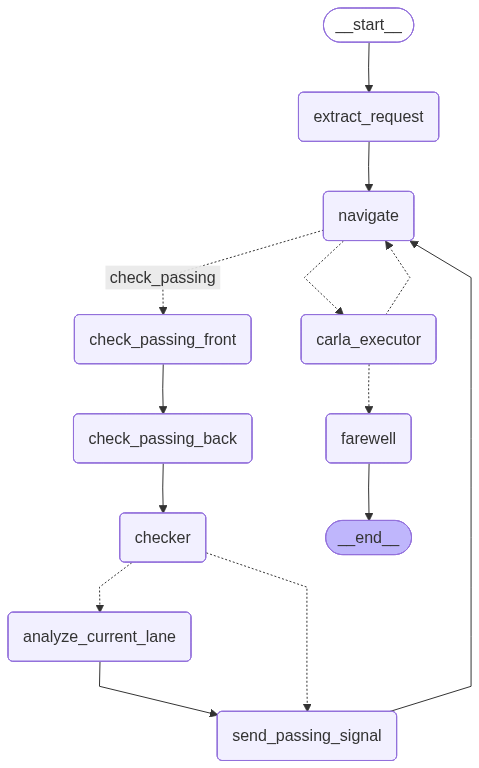

In [145]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [138]:
# Test

In [98]:
config = {"configurable": {"thread_id": "test-3"}}

initial_state = {
    "travel_request": "I need to get to the airport in 5 minutes",
    "messages": [],
}

for event in graph.stream(initial_state, config, stream_mode="updates"):
    node_name = list(event.keys())[0]
    if node_name == "__interrupt__":
        print(f"Question: {event['__interrupt__'][0].value}")
    else:
        for k, v in event[node_name].items():
            if k != "messages":
                print(f"  {k}: {v}")

Question: What is your current location?


In [99]:
print(graph.checkpointer)

In [100]:
from langgraph.types import Command

for event in graph.stream(Command(resume="Downtown Oak Boulevard"), config, stream_mode="updates"):
    node_name = list(event.keys())[0]
    if node_name == "__interrupt__":
        continue
    node_output = event[node_name]
    print(f"--- {node_name} ---")
    for k, v in node_output.items():
        if k != "messages":
            print(f"  {k}: {v}")
    break

--- extract_request ---
  starting_point: Downtown Oak Boulevard
  goal: airport
  aggressive_level: high
  original_aggressive_level: high
